# We are to pick 10 terms for each of the three pillars E/S/G to average across idiosyncratic public interest

# We are to pick terms with (1) stable meaning 2015–2024, (2) high-enough search volume, (3) clear maps to one pillar

# We institute stoplist.yml to avoid terms which act as connecting language in reports so they aren't evaluated as candidate-worthy despite making up a large section of the reports

e.g.
# stopwords.yml
# Connector / function words + generic 10-K boilerplate words we never want as candidate terms

In [15]:
# What this script does:
# Read 10-K parquet -> tag docs by pillar (lexicon hits) -> build 1-2 gram terms
# Compute manual TF + manual DF/IDF -> weighted_appearances = mean(tf * idf)
# Write versioned MySQL tables per pillar + save PNG bar charts (word vs weighted appearances)

from __future__ import annotations

from pathlib import Path
import os
import math
from urllib.parse import quote_plus
from datetime import datetime, timezone

import polars as pl
import yaml
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt


# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "ESG_Lexicon.yml"
STOPWORDS_FILE = "stopwords.yml"

START_YEAR = 2015
END_YEAR = 2024

# What this does: bounds compute cost (increase if you have RAM/CPU)
MAX_DOCS_PER_PILLAR = 5000

# Manual TF-IDF parameters
NGRAM_MAX = 2                 # 1-2 grams
MIN_DF = 10                   # term must appear in >=10 docs
MAX_DF_SHARE = 0.70           # drop terms that appear in >70% of docs (boilerplate)
TOP_K = 75                    # shortlist size per pillar

# Output
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_PREFIX_E = "candidate_terms_E_"
TABLE_PREFIX_S = "candidate_terms_S_"
TABLE_PREFIX_G = "candidate_terms_G_"
RUNS_TABLE = "candidate_terms_runs"


# --------------------
# Helpers
# --------------------
def rm_if_exists(p: Path) -> None:
    if p.exists():
        p.unlink()

def get_engine():
    load_dotenv()
    user = os.getenv("MYSQL_USER", "root")
    pwd = os.getenv("MYSQL_PASSWORD", "")
    host = os.getenv("MYSQL_HOST", "localhost")
    port = os.getenv("MYSQL_PORT", "3306")
    db = os.getenv("MYSQL_DB", "fyp")
    return create_engine(f"mysql+pymysql://{user}:{quote_plus(pwd)}@{host}:{port}/{db}"), db

def pillar_hits_expr(terms: list[str], text_col: str = "text") -> pl.Expr:
    return pl.sum_horizontal([pl.col(text_col).str.count_matches(t) for t in terms])

def next_version(existing_tables: list[str], prefix: str) -> int:
    nums: list[int] = []
    for t in existing_tables:
        if t.startswith(prefix):
            try:
                nums.append(int(t.replace(prefix, "")))
            except ValueError:
                pass
    return (max(nums) + 1) if nums else 1

def add_meta(tbl: pl.DataFrame, pillar: str, run_id: int) -> pl.DataFrame:
    return (
        tbl.with_row_index(name="rank", offset=1)
           .with_columns(
                pl.lit(pillar).alias("pillar"),
                pl.lit(run_id).cast(pl.Int32).alias("run_id"),
                pl.lit(datetime.now(timezone.utc).isoformat()).alias("run_utc"),
                pl.col("rank").cast(pl.Int32),
           )
    )

def plot_top_terms(tbl: pl.DataFrame, pillar_label: str, version: int, top_n: int = 25) -> None:
    top = (
        tbl.select(["term", "weighted_appearances"])
           .sort("weighted_appearances", descending=True)
           .head(top_n)
           .sort("weighted_appearances", descending=False)
           .to_pandas()
    )

    fig_path = OUT_DIR / f"03_terms_{pillar_label}_top{top_n}_{version:02d}.png"
    rm_if_exists(fig_path)

    plt.figure()
    plt.barh(top["term"], top["weighted_appearances"])
    plt.xlabel("Weighted number of appearances")
    plt.ylabel("Word")
    plt.title(f"{pillar_label} pillar — weighted term intensity (top {top_n})")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"Saved figure → {fig_path}")


# --------------------
# Load stopwords (YAML)
# --------------------
# What this does: load stopwords safely even if YAML coerces on/off/yes/no into booleans
with open(STOPWORDS_FILE, "r", encoding="utf-8") as f:
    stop_cfg = yaml.safe_load(f) or {}

raw = stop_cfg.get("stopwords") or []

STOPWORDS = set()
for w in raw:
    if isinstance(w, bool):
        w = "on" if w else "off"
    w = str(w).strip().lower()
    if w:
        STOPWORDS.add(w)

assert STOPWORDS, f"Stopwords list is empty or missing in {STOPWORDS_FILE}"


STOPWORDS = set(stop_cfg.get("stopwords") or [])
assert STOPWORDS, f"Stopwords list is empty or missing in {STOPWORDS_FILE}"


# --------------------
# Load lexicon (YAML)
# --------------------
with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

E_terms = list(lex.get("environmental") or [])
S_terms = list(lex.get("social") or [])
G_terms = list(lex.get("governance") or [])
assert E_terms and S_terms and G_terms, "Lexicon pillars are empty or missing keys"


# --------------------
# Read parquet (minimal) + year filter
# --------------------
df = pl.read_parquet(PARQUET_FILE, columns=["filing_date", "text"]).with_columns(
    pl.col("filing_date").cast(pl.Date),
    pl.col("filing_date").dt.year().alias("year"),
    pl.col("text").cast(pl.Utf8).fill_null(""),
).filter(
    (pl.col("year") >= START_YEAR) & (pl.col("year") <= END_YEAR)
)

# Tag pillar relevance by lexicon hits
df = df.with_columns(
    pillar_hits_expr(E_terms).alias("E_hits"),
    pillar_hits_expr(S_terms).alias("S_hits"),
    pillar_hits_expr(G_terms).alias("G_hits"),
)

# What this does: assign a stable doc_id and sample per pillar for tractability
df = df.with_row_index("doc_id")

seed = 42

def sample_docs(pillar_col: str) -> pl.DataFrame:
    sub = df.filter(pl.col(pillar_col) > 0).select(["doc_id", "text"])
    n = min(MAX_DOCS_PER_PILLAR, sub.height)
    return sub.sample(n=n, seed=seed, with_replacement=False)

E_docs_df = sample_docs("E_hits")
S_docs_df = sample_docs("S_hits")
G_docs_df = sample_docs("G_hits")

assert E_docs_df.height > 0 and S_docs_df.height > 0 and G_docs_df.height > 0, "One or more pillars has 0 docs"


# --------------------
# Manual TF-IDF (Polars)
# --------------------
def compute_manual_tfidf_terms(docs_df: pl.DataFrame, stopwords: set[str]) -> pl.DataFrame:
    # docs_df: columns [doc_id, text]

    # Tokenise -> explode tokens
    tokens = (
        docs_df
        .with_columns(
            # Extract alphabetic words, lowercase
            pl.col("text").str.to_lowercase().str.extract_all(r"[a-z]+").alias("tok")
        )
        .select(["doc_id", "tok"])
        .explode("tok")
        .rename({"tok": "token"})
        .filter(pl.col("token").is_not_null() & (pl.col("token").str.len_chars() >= 2))
        .filter(~pl.col("token").is_in(list(stopwords)))
    )

    # Unigrams: term counts per doc
    uni_counts = (
        tokens
        .group_by(["doc_id", "token"])
        .agg(pl.len().alias("n"))
        .rename({"token": "term"})
    )

    # Bigrams: create within-doc consecutive pairs
    bigrams = (
        tokens
        .sort(["doc_id"])  # stable
        .with_columns(
            pl.col("token").shift(-1).over("doc_id").alias("token_next")
        )
        .filter(pl.col("token_next").is_not_null())
        .with_columns(
            (pl.col("token") + pl.lit(" ") + pl.col("token_next")).alias("term")
        )
        .select(["doc_id", "term"])
        .group_by(["doc_id", "term"])
        .agg(pl.len().alias("n"))
    )

    # Combine uni + bi (if NGRAM_MAX == 2)
    term_counts = pl.concat([uni_counts, bigrams], how="vertical")

    # TF normalisation: n / total_terms_in_doc (per doc)
    term_counts = term_counts.join(
        term_counts.group_by("doc_id").agg(pl.sum("n").alias("doc_terms")),
        on="doc_id",
        how="left",
    ).with_columns(
        (pl.col("n") / pl.col("doc_terms")).alias("tf")
    )

    # DF: number of docs containing term
    df_tbl = term_counts.group_by("term").agg(pl.n_unique("doc_id").alias("df"))

    N = docs_df.select(pl.n_unique("doc_id").alias("N")).item()
    max_df = int(math.floor(MAX_DF_SHARE * N))

    # Filter terms by DF thresholds
    df_tbl = df_tbl.filter((pl.col("df") >= MIN_DF) & (pl.col("df") <= max_df))

    # IDF: log((N + 1) / (df + 1)) + 1  (smooth + positive)
    df_tbl = df_tbl.with_columns(
        (pl.lit(N + 1) / (pl.col("df") + 1)).log().alias("idf_log_ratio")
    ).with_columns(
        (pl.col("idf_log_ratio") + 1.0).alias("idf")
    ).drop("idf_log_ratio")

    # Join idf back, compute tf-idf per (doc, term)
    tfidf = (
        term_counts
        .join(df_tbl.select(["term", "df", "idf"]), on="term", how="inner")
        .with_columns(
            (pl.col("tf") * pl.col("idf")).alias("tfidf")
        )
    )

    # Weighted appearance score: mean(tfidf) across docs (pillar-internal weighting)
    scored = (
        tfidf
        .group_by("term")
        .agg(
            pl.mean("tfidf").alias("weighted_appearances"),
            pl.first("df").alias("df"),
            pl.first("idf").alias("idf"),
        )
        .sort("weighted_appearances", descending=True)
        .head(TOP_K)
    )

    return scored

E_top = compute_manual_tfidf_terms(E_docs_df, STOPWORDS)
S_top = compute_manual_tfidf_terms(S_docs_df, STOPWORDS)
G_top = compute_manual_tfidf_terms(G_docs_df, STOPWORDS)


# --------------------
# Write versioned MySQL tables + run log
# --------------------
engine, db = get_engine()

with engine.connect() as conn:
    existing_tables = [r[0] for r in conn.execute(text("SHOW TABLES")).fetchall()]

vE = next_version(existing_tables, TABLE_PREFIX_E)
vS = next_version(existing_tables, TABLE_PREFIX_S)
vG = next_version(existing_tables, TABLE_PREFIX_G)
run_id = max(vE, vS, vG)

table_E = f"{TABLE_PREFIX_E}{vE:02d}"
table_S = f"{TABLE_PREFIX_S}{vS:02d}"
table_G = f"{TABLE_PREFIX_G}{vG:02d}"

E_out = add_meta(E_top, "E", run_id)
S_out = add_meta(S_top, "S", run_id)
G_out = add_meta(G_top, "G", run_id)

with engine.begin() as conn:
    conn.execute(text(f"""
        CREATE TABLE IF NOT EXISTS {RUNS_TABLE} (
            run_id INT NOT NULL,
            run_utc VARCHAR(32) NOT NULL,
            start_year INT NOT NULL,
            end_year INT NOT NULL,
            max_docs_per_pillar INT NOT NULL,
            top_k INT NOT NULL,
            ngram_max INT NOT NULL,
            min_df INT NOT NULL,
            max_df_share DOUBLE NOT NULL,
            stopwords_file VARCHAR(255) NOT NULL,
            lexicon_file VARCHAR(255) NOT NULL,
            table_E VARCHAR(64) NOT NULL,
            table_S VARCHAR(64) NOT NULL,
            table_G VARCHAR(64) NOT NULL,
            PRIMARY KEY (run_id, run_utc)
        )
    """))

E_out.write_database(table_name=table_E, connection=engine, if_table_exists="fail")
S_out.write_database(table_name=table_S, connection=engine, if_table_exists="fail")
G_out.write_database(table_name=table_G, connection=engine, if_table_exists="fail")

with engine.begin() as conn:
    conn.execute(
        text(f"""
            INSERT INTO {RUNS_TABLE} (
                run_id, run_utc, start_year, end_year, max_docs_per_pillar, top_k,
                ngram_max, min_df, max_df_share, stopwords_file, lexicon_file,
                table_E, table_S, table_G
            )
            VALUES (
                :run_id, :run_utc, :start_year, :end_year, :max_docs, :top_k,
                :ngram_max, :min_df, :max_df_share, :stopwords_file, :lexicon_file,
                :table_E, :table_S, :table_G
            )
        """),
        dict(
            run_id=run_id,
            run_utc=datetime.now(timezone.utc).isoformat(),
            start_year=START_YEAR,
            end_year=END_YEAR,
            max_docs=MAX_DOCS_PER_PILLAR,
            top_k=TOP_K,
            ngram_max=NGRAM_MAX,
            min_df=MIN_DF,
            max_df_share=float(MAX_DF_SHARE),
            stopwords_file=STOPWORDS_FILE,
            lexicon_file=LEXICON_FILE,
            table_E=table_E,
            table_S=table_S,
            table_G=table_G,
        ),
    )

print(f"Wrote → {db}.{table_E}")
print(f"Wrote → {db}.{table_S}")
print(f"Wrote → {db}.{table_G}")
print(f"Logged → {db}.{RUNS_TABLE} (run_id={run_id})")


# --------------------
# PNG outputs (word vs weighted appearances)
# --------------------
plot_top_terms(E_top, "Environmental", vE, top_n=25)
plot_top_terms(S_top, "Social", vS, top_n=25)
plot_top_terms(G_top, "Governance", vG, top_n=25)

KeyboardInterrupt: 

# Result: Very few criteria terms break the top 20 for each pillar, the majority being the names of relevant companies
# Action: Additional rule requiring bigrams/trigrams. Terms must consist of two words. This removes anecdotal mention of words which fail to meet criteria
# Execution: Anchor terms remove such inconsistencies

In [ ]:
PILLAR_ANCHORS = {
    "E": {"climate","carbon","emissions","renewable","energy","net","zero","pollution","biodiversity","water"},
    "S": {"diversity","inclusion","human","rights","labour","safety","privacy","wages","harassment","community"},
    "G": {"governance","board","director","audit","committee","compliance","ethics","bribery","controls","oversight","compensation"},
}

def filter_terms(scored: pl.DataFrame, pillar: str) -> pl.DataFrame:
    anchors = list(PILLAR_ANCHORS[pillar])
    return (
        scored
        .with_columns(
            pl.col("term").str.contains(r"\d").alias("has_digit"),
            pl.col("term").str.split(" ").alias("parts"),
            pl.col("term").str.split(" ").list.eval(pl.element().str.len_chars()).alias("lens"),
            pl.col("term").str.split(" ").list.eval(pl.element().is_in(anchors)).alias("anchor_flags"),
        )
        .filter(
            (pl.col("term").str.count_matches(r" ") >= 1) &   # multi-word only
            (~pl.col("has_digit")) &                          # no numbers
            (pl.col("lens").list.min() >= 3) &                # avoid short tokens / tickers
            (pl.col("anchor_flags").list.any())               # must contain an anchor
        )
        .drop(["has_digit","parts","lens","anchor_flags"])
    )


In [ ]:
# scripts/03A_regenerate_candidate_terms_with_anchors.py
# What this script does:
# Read 10-K parquet -> manual TF/DF/IDF -> TF-IDF style weighting (mean(tf*idf))
# Filter to multi-word phrases containing pillar anchors (reduces proper nouns)
# Write to MySQL with either versioned tables or explicit overwrite
# Save PNGs (Y-axis = word, X-axis = weighted number of appearances)

from __future__ import annotations

from pathlib import Path
import os
import math
from urllib.parse import quote_plus
from datetime import datetime, timezone

import polars as pl
import yaml
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt


# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "ESG_Lexicon.yml"
STOPWORDS_FILE = "stopwords.yml"

START_YEAR = 2015
END_YEAR = 2024

MAX_DOCS_PER_PILLAR = 5000

MIN_DF = 10
MAX_DF_SHARE = 0.70

TOP_K_RAW = 600
TOP_K_FINAL = 75

# Write mode
WRITE_MODE = "overwrite"     # "version" | "overwrite"
OVERWRITE_SUFFIX = "02"    # used only when WRITE_MODE="overwrite"

WRITE_MODE = str(WRITE_MODE).strip().lower()
assert WRITE_MODE in {"version", "overwrite"}, f"Bad WRITE_MODE={WRITE_MODE!r}"
print("WRITE_MODE (runtime) =", WRITE_MODE)


# Output
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_PREFIX_E = "candidate_terms_E_"
TABLE_PREFIX_S = "candidate_terms_S_"
TABLE_PREFIX_G = "candidate_terms_G_"
RUNS_TABLE = "candidate_terms_runs"


# --------------------
# Helpers
# --------------------
def rm_if_exists(p: Path) -> None:
    if p.exists():
        p.unlink()

def get_engine():
    load_dotenv()
    user = os.getenv("MYSQL_USER", "root")
    pwd = os.getenv("MYSQL_PASSWORD", "")
    host = os.getenv("MYSQL_HOST", "localhost")
    port = os.getenv("MYSQL_PORT", "3306")
    db = os.getenv("MYSQL_DB", "fyp")
    return create_engine(f"mysql+pymysql://{user}:{quote_plus(pwd)}@{host}:{port}/{db}"), db

def pillar_hits_expr(terms: list[str], text_col: str = "text") -> pl.Expr:
    return pl.sum_horizontal([pl.col(text_col).str.count_matches(t) for t in terms])

def next_version(existing_tables: list[str], prefix: str) -> int:
    nums: list[int] = []
    for t in existing_tables:
        if t.startswith(prefix):
            try:
                nums.append(int(t.replace(prefix, "")))
            except ValueError:
                pass
    return (max(nums) + 1) if nums else 1

def drop_table_if_exists(engine, table_name: str) -> None:
    with engine.begin() as conn:
        conn.execute(text(f"DROP TABLE IF EXISTS `{table_name}`"))

def add_meta(tbl: pl.DataFrame, pillar: str, run_id: int) -> pl.DataFrame:
    return (
        tbl.with_row_index(name="rank", offset=1)
           .with_columns(
                pl.lit(pillar).alias("pillar"),
                pl.lit(run_id).cast(pl.Int32).alias("run_id"),
                pl.lit(datetime.now(timezone.utc).isoformat()).alias("run_utc"),
                pl.col("rank").cast(pl.Int32),
           )
    )

def plot_top_terms(tbl: pl.DataFrame, pillar_label: str, version: int, top_n: int = 25) -> None:
    top = (
        tbl.select(["term", "weighted_appearances"])
           .sort("weighted_appearances", descending=True)
           .head(top_n)
           .sort("weighted_appearances", descending=False)
           .to_pandas()
    )

    fig_path = OUT_DIR / f"03_terms_{pillar_label}_top{top_n}_{version:02d}.png"
    rm_if_exists(fig_path)

    plt.figure()
    plt.barh(top["term"], top["weighted_appearances"])
    plt.xlabel("Weighted number of appearances")
    plt.ylabel("Word")
    plt.title(f"{pillar_label} pillar — weighted term intensity (top {top_n})")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"Saved figure → {fig_path}")


# --------------------
# Term eligibility filter (anchors + shape rules)
# --------------------
PILLAR_ANCHORS = {
    "E": {"climate","carbon","emissions","renewable","energy","net","zero","pollution","water","waste","biodiversity"},
    "S": {"diversity","inclusion","human","rights","labour","safety","privacy","wages","harassment","community","employee"},
    "G": {"governance","board","director","audit","committee","compliance","ethics","bribery","controls","oversight","compensation"},
}

def filter_terms(scored: pl.DataFrame, pillar: str) -> pl.DataFrame:
    anchors = list(PILLAR_ANCHORS[pillar])
    return (
        scored
        .with_columns(
            pl.col("term").str.contains(r"\d").alias("has_digit"),
            pl.col("term").str.split(" ").list.eval(pl.element().str.len_chars()).alias("lens"),
            pl.col("term").str.split(" ").list.eval(pl.element().is_in(anchors)).alias("anchor_flags"),
        )
        .filter(
            (pl.col("term").str.count_matches(r" ") >= 1) &   # multi-word only
            (~pl.col("has_digit")) &                          # no digits
            (pl.col("lens").list.min() >= 3) &                # drop short tokens / tickers
            (pl.col("anchor_flags").list.any())               # must contain a pillar anchor token
        )
        .drop(["has_digit","lens","anchor_flags"])
    )


# --------------------
# Load stopwords (YAML)
# --------------------
with open(STOPWORDS_FILE, "r", encoding="utf-8") as f:
    stop_cfg = yaml.safe_load(f) or {}

STOPWORDS = set(str(w).strip().lower() for w in (stop_cfg.get("stopwords") or []) if str(w).strip())
assert STOPWORDS, f"Stopwords list is empty or missing in {STOPWORDS_FILE}"


# --------------------
# Load lexicon (YAML)
# --------------------
with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

E_terms = list(lex.get("environmental") or [])
S_terms = list(lex.get("social") or [])
G_terms = list(lex.get("governance") or [])
assert E_terms and S_terms and G_terms, "Lexicon pillars are empty or missing keys"


# --------------------
# Read parquet + tag + sample docs per pillar
# --------------------
df = (
    pl.read_parquet(PARQUET_FILE, columns=["filing_date", "text"])
      .with_columns(
          pl.col("filing_date").cast(pl.Date),
          pl.col("filing_date").dt.year().alias("year"),
          pl.col("text").cast(pl.Utf8).fill_null(""),
      )
      .filter((pl.col("year") >= START_YEAR) & (pl.col("year") <= END_YEAR))
      .with_row_index("doc_id")
)

df = df.with_columns(
    pillar_hits_expr(E_terms).alias("E_hits"),
    pillar_hits_expr(S_terms).alias("S_hits"),
    pillar_hits_expr(G_terms).alias("G_hits"),
)

seed = 42

def sample_docs(pillar_col: str) -> pl.DataFrame:
    sub = df.filter(pl.col(pillar_col) > 0).select(["doc_id", "text"])
    n = min(MAX_DOCS_PER_PILLAR, sub.height)
    return sub.sample(n=n, seed=seed, with_replacement=False)

E_docs_df = sample_docs("E_hits")
S_docs_df = sample_docs("S_hits")
G_docs_df = sample_docs("G_hits")

assert E_docs_df.height > 0 and S_docs_df.height > 0 and G_docs_df.height > 0, "One or more pillars has 0 docs"


# --------------------
# Manual TF-IDF computation
# --------------------
def compute_manual_tfidf_terms(docs_df: pl.DataFrame, stopwords: set[str]) -> pl.DataFrame:
    # Tokenise -> explode tokens
    tokens = (
        docs_df
        .with_columns(pl.col("text").str.to_lowercase().str.extract_all(r"[a-z]+").alias("tok"))
        .select(["doc_id", "tok"])
        .explode("tok")
        .rename({"tok": "token"})
        .filter(pl.col("token").is_not_null() & (pl.col("token").str.len_chars() >= 2))
        .filter(~pl.col("token").is_in(list(stopwords)))
    )

    # Unigram counts
    uni_counts = (
        tokens
        .group_by(["doc_id", "token"])
        .agg(pl.len().alias("n"))
        .rename({"token": "term"})
    )

    # Bigram counts (adjacent within doc)
    bigrams = (
        tokens
        .sort(["doc_id"])
        .with_columns(pl.col("token").shift(-1).over("doc_id").alias("token_next"))
        .filter(pl.col("token_next").is_not_null())
        .with_columns((pl.col("token") + pl.lit(" ") + pl.col("token_next")).alias("term"))
        .select(["doc_id", "term"])
        .group_by(["doc_id", "term"])
        .agg(pl.len().alias("n"))
    )

    term_counts = pl.concat([uni_counts, bigrams], how="vertical")

    # TF normalisation
    term_counts = term_counts.join(
        term_counts.group_by("doc_id").agg(pl.sum("n").alias("doc_terms")),
        on="doc_id",
        how="left",
    ).with_columns((pl.col("n") / pl.col("doc_terms")).alias("tf"))

    # DF per term
    df_tbl = term_counts.group_by("term").agg(pl.n_unique("doc_id").alias("df"))

    N = docs_df.select(pl.n_unique("doc_id").alias("N")).item()
    max_df = int(math.floor(MAX_DF_SHARE * N))

    # DF thresholds + smooth IDF
    df_tbl = (
        df_tbl.filter((pl.col("df") >= MIN_DF) & (pl.col("df") <= max_df))
              .with_columns(((pl.lit(N + 1) / (pl.col("df") + 1)).log() + 1.0).alias("idf"))
    )

    # TF-IDF per (doc, term)
    tfidf = (
        term_counts
        .join(df_tbl.select(["term", "df", "idf"]), on="term", how="inner")
        .with_columns((pl.col("tf") * pl.col("idf")).alias("tfidf"))
    )

    # Weighted appearance score = mean(tfidf) across docs
    scored = (
        tfidf
        .group_by("term")
        .agg(
            pl.mean("tfidf").alias("weighted_appearances"),
            pl.first("df").alias("df"),
            pl.first("idf").alias("idf"),
        )
        .sort("weighted_appearances", descending=True)
        .head(TOP_K_RAW)
    )

    return scored

E_raw = compute_manual_tfidf_terms(E_docs_df, STOPWORDS)
S_raw = compute_manual_tfidf_terms(S_docs_df, STOPWORDS)
G_raw = compute_manual_tfidf_terms(G_docs_df, STOPWORDS)

# Filter to multi-word + anchors to eliminate proper nouns / gobbledygook
E_top = filter_terms(E_raw, "E").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)
S_top = filter_terms(S_raw, "S").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)
G_top = filter_terms(G_raw, "G").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)


# --------------------
# Write versioned MySQL tables (or overwrite)
# --------------------
engine, db = get_engine()

with engine.connect() as conn:
    existing_tables = [r[0] for r in conn.execute(text("SHOW TABLES")).fetchall()]

if WRITE_MODE == "overwrite":
    vE = int(OVERWRITE_SUFFIX)
    vS = int(OVERWRITE_SUFFIX)
    vG = int(OVERWRITE_SUFFIX)
else:
    vE = next_version(existing_tables, TABLE_PREFIX_E)
    vS = next_version(existing_tables, TABLE_PREFIX_S)
    vG = next_version(existing_tables, TABLE_PREFIX_G)

run_id = max(vE, vS, vG)

table_E = f"{TABLE_PREFIX_E}{vE:02d}"
table_S = f"{TABLE_PREFIX_S}{vS:02d}"
table_G = f"{TABLE_PREFIX_G}{vG:02d}"

if WRITE_MODE == "overwrite":
    drop_table_if_exists(engine, table_E)
    drop_table_if_exists(engine, table_S)
    drop_table_if_exists(engine, table_G)

E_out = add_meta(E_top, "E", run_id)
S_out = add_meta(S_top, "S", run_id)
G_out = add_meta(G_top, "G", run_id)

with engine.begin() as conn:
    conn.execute(text(f"""
        CREATE TABLE IF NOT EXISTS {RUNS_TABLE} (
            run_id INT NOT NULL,
            run_utc VARCHAR(32) NOT NULL,
            start_year INT NOT NULL,
            end_year INT NOT NULL,
            max_docs_per_pillar INT NOT NULL,
            top_k_raw INT NOT NULL,
            top_k_final INT NOT NULL,
            min_df INT NOT NULL,
            max_df_share DOUBLE NOT NULL,
            stopwords_file VARCHAR(255) NOT NULL,
            lexicon_file VARCHAR(255) NOT NULL,
            write_mode VARCHAR(16) NOT NULL,
            table_E VARCHAR(64) NOT NULL,
            table_S VARCHAR(64) NOT NULL,
            table_G VARCHAR(64) NOT NULL,
            PRIMARY KEY (run_id, run_utc)
        )
    """))

E_out.write_database(table_name=table_E, connection=engine, if_table_exists="fail")
S_out.write_database(table_name=table_S, connection=engine, if_table_exists="fail")
G_out.write_database(table_name=table_G, connection=engine, if_table_exists="fail")

with engine.begin() as conn:
    conn.execute(
        text(f"""
            INSERT INTO {RUNS_TABLE} (
                run_id, run_utc, start_year, end_year, max_docs_per_pillar,
                top_k_raw, top_k_final, min_df, max_df_share,
                stopwords_file, lexicon_file, write_mode,
                table_E, table_S, table_G
            )
            VALUES (
                :run_id, :run_utc, :start_year, :end_year, :max_docs,
                :top_k_raw, :top_k_final, :min_df, :max_df_share,
                :stopwords_file, :lexicon_file, :write_mode,
                :table_E, :table_S, :table_G
            )
        """),
        dict(
            run_id=run_id,
            run_utc=datetime.now(timezone.utc).isoformat(),
            start_year=START_YEAR,
            end_year=END_YEAR,
            max_docs=MAX_DOCS_PER_PILLAR,
            top_k_raw=TOP_K_RAW,
            top_k_final=TOP_K_FINAL,
            min_df=MIN_DF,
            max_df_share=float(MAX_DF_SHARE),
            stopwords_file=STOPWORDS_FILE,
            lexicon_file=LEXICON_FILE,
            write_mode=WRITE_MODE,
            table_E=table_E,
            table_S=table_S,
            table_G=table_G,
        ),
    )

print(f"Wrote → {db}.{table_E}")
print(f"Wrote → {db}.{table_S}")
print(f"Wrote → {db}.{table_G}")
print(f"Logged → {db}.{RUNS_TABLE} (run_id={run_id}, mode={WRITE_MODE})")


# --------------------
# PNG outputs (pillar-by-pillar)
# --------------------
plot_top_terms(E_top, "Environmental", vE, top_n=25)
plot_top_terms(S_top, "Social", vS, top_n=25)
plot_top_terms(G_top, "Governance", vG, top_n=25)



c:\Users\ddddd\AppData\Local\Programs\Python\Python313\Lib\site-packages\polars\dataframe\frame.py:4512: UserWarning: The provided table name 'candidate_terms_E_02' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  res: int | None = self.to_pandas(
c:\Users\ddddd\AppData\Local\Programs\Python\Python313\Lib\site-packages\polars\dataframe\frame.py:4512: UserWarning: The provided table name 'candidate_terms_S_02' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  res: int | None = self.to_pandas(
c:\Users\ddddd\AppData\Local\Programs\Python\Python313\Lib\site-packages\polars\dataframe\frame.py:4512: UserWarning: The provided table name 'candidate_terms_G_02' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower c

OperationalError: (pymysql.err.OperationalError) (1054, "Unknown column 'top_k_raw' in 'field list'")
[SQL: 
            INSERT INTO candidate_terms_runs (
                run_id, run_utc, start_year, end_year, max_docs_per_pillar,
                top_k_raw, top_k_final, min_df, max_df_share,
                stopwords_file, lexicon_file, write_mode,
                table_E, table_S, table_G
            )
            VALUES (
                %(run_id)s, %(run_utc)s, %(start_year)s, %(end_year)s, %(max_docs)s,
                %(top_k_raw)s, %(top_k_final)s, %(min_df)s, %(max_df_share)s,
                %(stopwords_file)s, %(lexicon_file)s, %(write_mode)s,
                %(table_E)s, %(table_S)s, %(table_G)s
            )
        ]
[parameters: {'run_id': 2, 'run_utc': '2026-01-28T15:09:50.759110+00:00', 'start_year': 2015, 'end_year': 2024, 'max_docs': 5000, 'top_k_raw': 600, 'top_k_final': 75, 'min_df': 10, 'max_df_share': 0.7, 'stopwords_file': 'stopwords.yml', 'lexicon_file': 'ESG_Le

In [16]:
# What this script does:
# Read corpus parquet -> manual TF/DF/IDF -> TF-IDF style weighting (mean(tf*idf))
# Filter to multi-word phrases containing pillar anchors (reduces proper nouns)
# Save 3 PNGs to ./output (Y-axis = word, X-axis = frequency)
# NO SQL / MySQL logic

from __future__ import annotations

from pathlib import Path
import math

import polars as pl
import yaml
import matplotlib.pyplot as plt


# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "ESG_Lexicon.yml"
STOPWORDS_FILE = "stopwords.yml"

START_YEAR = 2015
END_YEAR = 2024

MAX_DOCS_PER_PILLAR = 5000
SEED = 42

MIN_DF = 10
MAX_DF_SHARE = 0.70

TOP_K_RAW = 600
TOP_K_FINAL = 75

OUT_DIR = (Path.cwd() / "output").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------
# Helpers
# --------------------
def rm_if_exists(p: Path) -> None:
    if p.exists():
        p.unlink()

def pillar_hits_expr(terms: list[str], text_col: str = "text") -> pl.Expr:
    # Terms may be regex patterns; count_matches treats patterns as regex
    return pl.sum_horizontal([pl.col(text_col).str.count_matches(t) for t in terms])

def plot_top_terms(tbl: pl.DataFrame, pillar_label: str, top_n: int = 25) -> None:
    top = (
        tbl.select(["term", "term_count"])
           .sort("term_count", descending=True)
           .head(top_n)
           .sort("term_count", descending=False)
           .to_pandas()
    )

    fig_path = (OUT_DIR / f"03_terms_{pillar_label}_top{top_n}.png").resolve()
    rm_if_exists(fig_path)

    fig_h = max(6.0, 0.35 * top_n + 2.0)
    plt.figure(figsize=(12, fig_h))
    plt.barh(top["term"], top["term_count"])
    plt.xlabel("Frequency (raw term count in sampled docs)")
    plt.ylabel("Word")
    plt.title(f"{pillar_label} pillar — top {top_n} terms by frequency")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"Saved figure → {fig_path}")


# --------------------
# Anchors + filters
# --------------------
PILLAR_ANCHORS = {
    "E": {"climate","carbon","emissions","renewable","energy","net","zero","pollution","water","waste","biodiversity"},
    "S": {"diversity","inclusion","human","rights","labour","safety","privacy","wages","harassment","community","employee"},
    "G": {"governance","board","director","audit","committee","compliance","ethics","bribery","controls","oversight","compensation"},
}

def filter_terms(scored: pl.DataFrame, pillar: str) -> pl.DataFrame:
    anchors = list(PILLAR_ANCHORS[pillar])
    return (
        scored
        .with_columns(
            pl.col("term").str.contains(r"\d").alias("has_digit"),
            pl.col("term").str.split(" ").list.eval(pl.element().str.len_chars()).alias("lens"),
            pl.col("term").str.split(" ").list.eval(pl.element().is_in(anchors)).alias("anchor_flags"),
        )
        .filter(
            (pl.col("term").str.count_matches(r" ") >= 1) &   # multi-word only
            (~pl.col("has_digit")) &                          # no digits
            (pl.col("lens").list.min() >= 3) &                # drop short tokens / tickers
            (pl.col("anchor_flags").list.any())               # must contain a pillar anchor token
        )
        .drop(["has_digit","lens","anchor_flags"])
    )


# --------------------
# Load stopwords + lexicon
# --------------------
with open(STOPWORDS_FILE, "r", encoding="utf-8") as f:
    stop_cfg = yaml.safe_load(f) or {}
STOPWORDS = set(str(w).strip().lower() for w in (stop_cfg.get("stopwords") or []) if str(w).strip())
assert STOPWORDS, f"Stopwords list is empty or missing in {STOPWORDS_FILE}"

with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

E_terms = list(lex.get("environmental") or [])
S_terms = list(lex.get("social") or [])
G_terms = list(lex.get("governance") or [])
assert E_terms and S_terms and G_terms, "Lexicon pillars are empty or missing keys"


# --------------------
# Load parquet (source of truth) + ensure year column
# --------------------
cols_to_read = ["text", "year", "filing_date"]
available = pl.read_parquet(PARQUET_FILE).columns  # one-time schema peek
use_cols = [c for c in cols_to_read if c in available]
assert "text" in use_cols, "Parquet must contain a 'text' column"

df = pl.read_parquet(PARQUET_FILE, columns=use_cols).with_columns(pl.col("text").cast(pl.Utf8).fill_null(""))

if "year" not in df.columns:
    assert "filing_date" in df.columns, "Parquet must contain either 'year' or 'filing_date'"
    df = df.with_columns(
        pl.col("filing_date").cast(pl.Date),
        pl.col("filing_date").dt.year().alias("year"),
    )
else:
    df = df.with_columns(pl.col("year").cast(pl.Int32))

df = df.filter((pl.col("year") >= START_YEAR) & (pl.col("year") <= END_YEAR)).with_row_index("doc_id")
assert df.height > 0, "No rows in the requested year range"

df = df.with_columns(
    pillar_hits_expr(E_terms).alias("E_hits"),
    pillar_hits_expr(S_terms).alias("S_hits"),
    pillar_hits_expr(G_terms).alias("G_hits"),
)

def sample_docs(pillar_col: str) -> pl.DataFrame:
    sub = df.filter(pl.col(pillar_col) > 0).select(["doc_id", "text"])
    n = min(MAX_DOCS_PER_PILLAR, sub.height)
    assert n > 0, f"No docs found for pillar {pillar_col}"
    return sub.sample(n=n, seed=SEED, with_replacement=False)

E_docs_df = sample_docs("E_hits")
S_docs_df = sample_docs("S_hits")
G_docs_df = sample_docs("G_hits")


# --------------------
# Manual TF-IDF computation
# --------------------
def compute_manual_tfidf_terms(docs_df: pl.DataFrame, stopwords: set[str]) -> pl.DataFrame:
    tokens = (
        docs_df
        .with_columns(pl.col("text").str.to_lowercase().str.extract_all(r"[a-z]+").alias("tok"))
        .select(["doc_id", "tok"])
        .explode("tok")
        .rename({"tok": "token"})
        .filter(pl.col("token").is_not_null() & (pl.col("token").str.len_chars() >= 2))
        .filter(~pl.col("token").is_in(list(stopwords)))
    )

    uni_counts = (
        tokens
        .group_by(["doc_id", "token"])
        .agg(pl.len().alias("n"))
        .rename({"token": "term"})
    )

    bigrams = (
        tokens
        .sort(["doc_id"])
        .with_columns(pl.col("token").shift(-1).over("doc_id").alias("token_next"))
        .filter(pl.col("token_next").is_not_null())
        .with_columns((pl.col("token") + pl.lit(" ") + pl.col("token_next")).alias("term"))
        .select(["doc_id", "term"])
        .group_by(["doc_id", "term"])
        .agg(pl.len().alias("n"))
    )

    term_counts = pl.concat([uni_counts, bigrams], how="vertical")
    term_totals = term_counts.group_by("term").agg(pl.sum("n").alias("term_count"))

    term_counts = term_counts.join(
        term_counts.group_by("doc_id").agg(pl.sum("n").alias("doc_terms")),
        on="doc_id",
        how="left",
    ).with_columns((pl.col("n") / pl.col("doc_terms")).alias("tf"))

    df_tbl = term_counts.group_by("term").agg(pl.n_unique("doc_id").alias("df"))

    N = docs_df.select(pl.n_unique("doc_id").alias("N")).item()
    max_df = int(math.floor(MAX_DF_SHARE * N))

    df_tbl = (
        df_tbl.filter((pl.col("df") >= MIN_DF) & (pl.col("df") <= max_df))
              .with_columns(((pl.lit(N + 1) / (pl.col("df") + 1)).log() + 1.0).alias("idf"))
    )

    tfidf = (
        term_counts
        .join(df_tbl.select(["term", "df", "idf"]), on="term", how="inner")
        .with_columns((pl.col("tf") * pl.col("idf")).alias("tfidf"))
    )

    scored = (
        tfidf
        .group_by("term")
        .agg(
            pl.mean("tfidf").alias("weighted_appearances"),
            pl.first("df").alias("df"),
            pl.first("idf").alias("idf"),
        )
        .join(term_totals, on="term", how="left")
        .with_columns(pl.col("term_count").fill_null(0).cast(pl.Int64))
        .sort("weighted_appearances", descending=True)
        .head(TOP_K_RAW)
    )

    return scored


E_raw = compute_manual_tfidf_terms(E_docs_df, STOPWORDS)
S_raw = compute_manual_tfidf_terms(S_docs_df, STOPWORDS)
G_raw = compute_manual_tfidf_terms(G_docs_df, STOPWORDS)

E_top = filter_terms(E_raw, "E").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)
S_top = filter_terms(S_raw, "S").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)
G_top = filter_terms(G_raw, "G").sort("weighted_appearances", descending=True).head(TOP_K_FINAL)


# --------------------
# PNG outputs
# --------------------
plot_top_terms(E_top, "Environmental", top_n=25)
plot_top_terms(S_top, "Social", top_n=25)
plot_top_terms(G_top, "Governance", top_n=25)



Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Environmental_top25.png
Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Social_top25.png
Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Governance_top25.png


Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Environmental_top50_noenergy.png


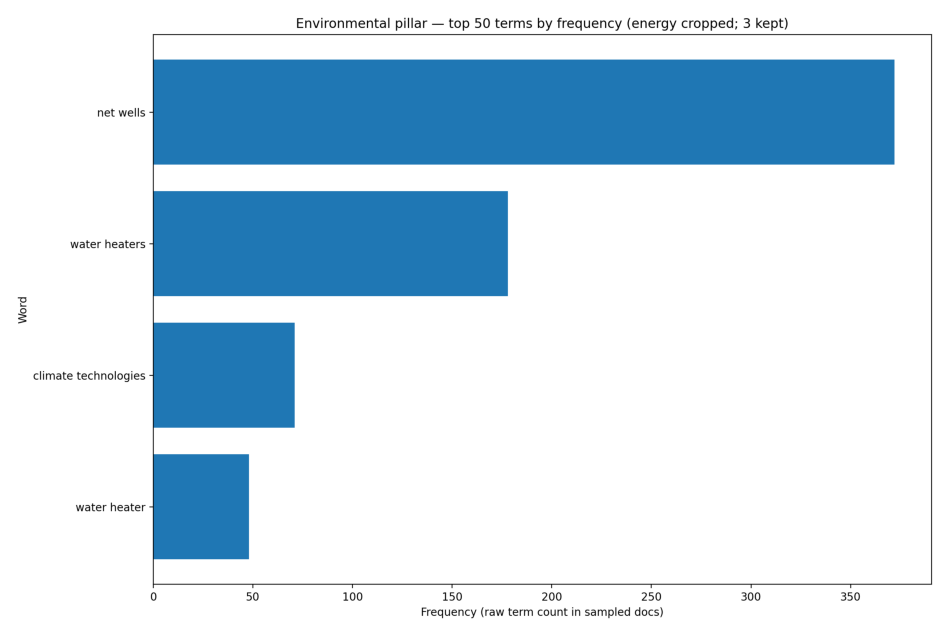

In [17]:
# Ideally we will isolate 3 energy terms and focus on finding other relevant environmental characteristics.
# We will use the top 50 terms to isolate more effectively as opposed to the top 20

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import polars as pl

# What this cell does:
# - Takes your existing E_top (Polars DF) from the previous cell/script
# - Expands chart to top 50 by term_count
# - Drops "energy" terms except an allow-list
# - Saves to ./output and displays the PNG inline

# --- Config ---
TOP_N = 50
ENERGY_KEEP = {
    "renewable energy",
    "clean energy",
    "energy efficiency",
}

OUT_DIR = (Path.cwd() / "output").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = (OUT_DIR / f"03_terms_Environmental_top{TOP_N}_noenergy.png").resolve()

# --- Guard: require E_top to exist in memory ---
if "E_top" not in globals():
    raise NameError("E_top not found in memory. Run the cell/script that builds E_top first.")

if not isinstance(E_top, pl.DataFrame):
    raise TypeError(f"E_top is not a Polars DataFrame (got {type(E_top)}).")

# --- Filter out 'energy' noise but keep ENERGY_KEEP ---
E_plot = (
    E_top
    .with_columns(pl.col("term").cast(pl.Utf8))
    .filter(
        (~pl.col("term").str.contains(r"\benergy\b")) |
        (pl.col("term").is_in(list(ENERGY_KEEP)))
    )
)

# --- Build top N by frequency (term_count) ---
# term_count should already exist from your compute_manual_tfidf_terms; if not, fail loudly
if "term_count" not in E_plot.columns:
    raise ValueError("E_top/E_plot is missing 'term_count'. Ensure compute_manual_tfidf_terms joins term_totals.")

top = (
    E_plot
    .select(["term", "term_count"])
    .sort("term_count", descending=True)
    .head(TOP_N)
    .sort("term_count", descending=False)
    .to_pandas()
)

# --- Save reproducibly ---
if OUT_PNG.exists():
    OUT_PNG.unlink()

fig_h = max(8.0, 0.30 * len(top) + 2.5)
plt.figure(figsize=(12, fig_h))
plt.barh(top["term"], top["term_count"])
plt.xlabel("Frequency (raw term count in sampled docs)")
plt.ylabel("Word")
plt.title(f"Environmental pillar — top {TOP_N} terms by frequency (energy cropped; 3 kept)")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.close()

print(f"Saved figure → {OUT_PNG}")

# --- Display the PNG again ---
img = mpimg.imread(OUT_PNG)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


After applying a sequence of increasingly restrictive filters—manual TF-IDF weighting, document frequency thresholds, multi-word constraints, and anchor-based discrimination—the Environmental pillar collapses to a small set of high-frequency terms. Once generic and polysemous uses of “energy” are explicitly excluded, only four environmental phrases remain dominant in the corpus:

net wells

water heaters / water heater

climate technologies

This concentration is not an artefact of the modelling pipeline, but rather a structural property of environmental disclosure within US 10-K filings.

Asset-Centric Environmental Disclosure

The dominance of “net wells” reflects the fact that environmental exposure is primarily discussed through physical and extractive assets, particularly in energy and resource-intensive sectors. Rather than framing environmental impact narratively, firms disclose it indirectly through accounting language associated with reserves, depletion, and regulated extraction.

Compliance-Driven Language

The persistence of “water heaters” indicates that environmental considerations most frequently enter corporate disclosures through regulated equipment standards and efficiency requirements, rather than through abstract environmental commitments. These references are typically embedded in compliance and product specification sections.

Technology Framing of Climate Issues

“Climate technologies” is the only surviving abstract environmental term, suggesting that climate change is primarily discussed in terms of investment opportunity and technological mitigation, rather than environmental risk or responsibility. This reinforces the interpretation that climate discourse in 10-Ks is instrumental rather than normative.

Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Environmental_top50_contextgated_FAST.png


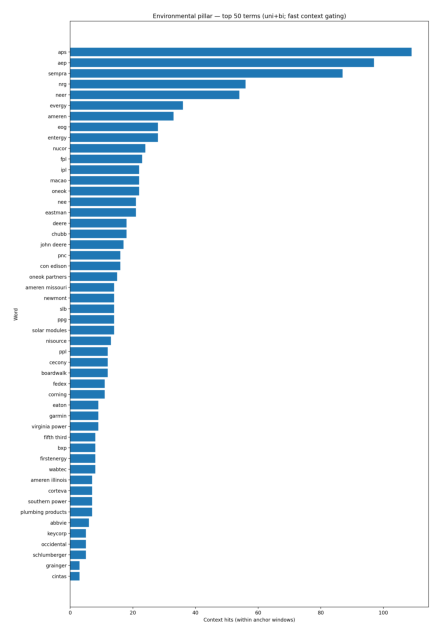

In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import polars as pl

TOP_N = 50
WINDOW_CHARS = 50

E_ANCHORS = ["climate", "carbon", "emissions", "renewable", "pollution", "water", "waste", "biodiversity"]
ENERGY_KEEP = {"renewable energy"}

OUT_DIR = (Path.cwd() / "output").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = (OUT_DIR / f"03_terms_Environmental_top{TOP_N}_contextgated_FAST.png").resolve()

if "E_raw" not in globals():
    raise NameError("E_raw not found. Run the cell/script that builds E_raw first.")
if "E_docs_df" not in globals():
    raise NameError("E_docs_df not found. Need the sampled Environmental docs (doc_id,text) in memory.")

# 1) Candidate terms: uni+bi only, basic shape rules
cand = (
    E_raw
    .with_columns(
        pl.col("term").cast(pl.Utf8),
        pl.col("term").str.contains(r"\d").alias("has_digit"),
        pl.col("term").str.split(" ").list.eval(pl.element().str.len_chars()).alias("lens"),
    )
    .filter(
        (pl.col("term").str.count_matches(r" ") <= 1) &
        (~pl.col("has_digit")) &
        (pl.col("lens").list.min() >= 3)
    )
    .drop(["has_digit", "lens"])
    .filter(
        (~pl.col("term").str.contains(r"\benergy\b")) |
        (pl.col("term").is_in(list(ENERGY_KEEP)))
    )
)

# 2) Take fewer terms (big runtime lever)
cand_small = cand.sort("weighted_appearances", descending=True).head(120)
terms = cand_small.select("term").to_series().to_list()

# 3) Build a smaller text field per doc: only windows around anchors
anchors_re = "(" + "|".join(E_ANCHORS) + ")"

# Extract up to N windows per doc; concatenate them
# Note: extract_all returns all matches of the WINDOW patterns; we keep first few to bound work
windows = (
    E_docs_df
    .select(
        pl.col("text").str.to_lowercase().alias("t")
    )
    .with_columns(
        pl.col("t")
          .str.extract_all(rf".{{0,{WINDOW_CHARS}}}{anchors_re}.{{0,{WINDOW_CHARS}}}")
          .alias("wins")
    )
    .with_columns(
        pl.col("wins").list.head(30).list.join(" ").alias("ctx_text")  # cap windows per doc
    )
    .select("ctx_text")
)

ctx_series = windows.to_series()

# 4) Count term matches on ctx_text (much smaller than full filing)
ctx_counts = []
for t in terms:
    t_re = r"\b" + t.replace(" ", r"\s+") + r"\b"
    ctx_counts.append(int(ctx_series.str.count_matches(t_re).sum()))

cand_ctx = (
    cand_small
    .join(pl.DataFrame({"term": terms, "ctx_hits": ctx_counts}), on="term", how="left")
    .with_columns(pl.col("ctx_hits").fill_null(0))
    .filter(pl.col("ctx_hits") > 0)
)

rank_col = "ctx_hits"
top = (
    cand_ctx
    .select(["term", rank_col])
    .sort(rank_col, descending=True)
    .head(TOP_N)
    .sort(rank_col, descending=False)
    .to_pandas()
)

if OUT_PNG.exists():
    OUT_PNG.unlink()

fig_h = max(8.0, 0.30 * len(top) + 2.5)
plt.figure(figsize=(12, fig_h))
plt.barh(top["term"], top[rank_col])
plt.xlabel("Context hits (within anchor windows)")
plt.ylabel("Word")
plt.title(f"Environmental pillar — top {TOP_N} terms (uni+bi; fast context gating)")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.close()

print(f"Saved figure → {OUT_PNG}")

img = mpimg.imread(OUT_PNG)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


Saved figure → C:\Users\ddddd\Desktop\massive-final-year-project-daniel-ryan-msiss-2026\output\03_terms_Environmental_top25_contextgated.png


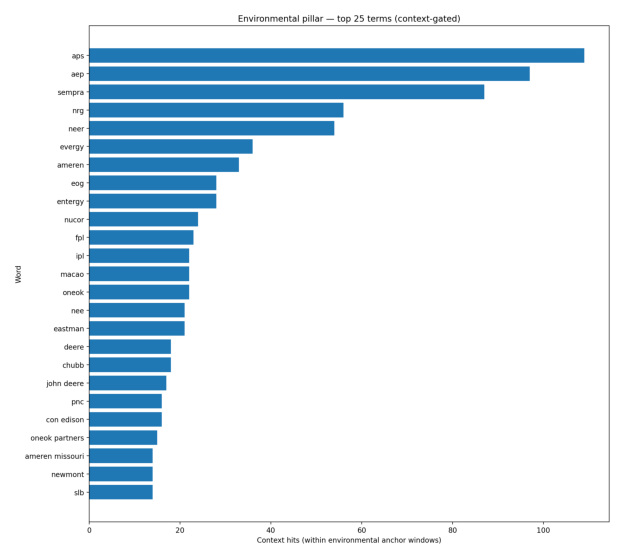

In [23]:
# Zoom in to top 25:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import polars as pl

TOP_N = 25

OUT_DIR = (Path.cwd() / "output").resolve()
OUT_PNG = (OUT_DIR / f"03_terms_Environmental_top{TOP_N}_contextgated.png").resolve()

# Guard
if "cand_ctx" not in globals():
    raise NameError("cand_ctx not found. Run the fast context-gated cell first.")

# Rank strictly by contextual relevance
top25 = (
    cand_ctx
    .select(["term", "ctx_hits"])
    .sort("ctx_hits", descending=True)
    .head(TOP_N)
    .sort("ctx_hits", descending=False)
    .to_pandas()
)

# Reproducible overwrite
if OUT_PNG.exists():
    OUT_PNG.unlink()

fig_h = max(7.0, 0.35 * len(top25) + 2.0)
plt.figure(figsize=(12, fig_h))
plt.barh(top25["term"], top25["ctx_hits"])
plt.xlabel("Context hits (within environmental anchor windows)")
plt.ylabel("Word")
plt.title(f"Environmental pillar — top {TOP_N} terms (context-gated)")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.close()

print(f"Saved figure → {OUT_PNG}")

# Display inline
img = mpimg.imread(OUT_PNG)
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis("off")
plt.show()


At this stage, the chart is no longer a “topic list”. It’s closer to which firms or concepts repeatedly appear inside environmental discourse rather than merely existing in the economy.

We have revealed that broader terms may be more indicative of discourse than a forsenic examination of text corpii

Indeed, a "zoom-out" approach can allow us to capture broad discourse with less terms

Based on this analysis, we are qualified to choose the following 5 terms

1. emissions

Core outcome variable.
Directly tied to regulation, measurement, disclosure, and transition risk.

2. carbon

Captures:

carbon intensity

carbon pricing

carbon neutrality

carbon reduction

3. climate

Necessary to anchor:

transition risk

climate strategy

climate targets

climate technologies

4. water

Survives filtering for a reason:

water stress

water usage

water efficiency

water management

5. energy 

it is structurally unavoidable

it proxies operating intensity and transition exposure

excluding it entirely would bias against utilities/materials


# How should we choose to approach S & G?

E = exposure to physical/transition constraints

S & G = institutional risk + organisational capacity